# Cancer Growth Dynamics: Treated MonoCulture Analysis
## IC25, IC50, IC75 Dose Response Modeling (20k Density)

**Fixed Drug Concentrations:**
- IC25: 1.47 µM (25% inhibition target) 
- IC50: 1.00 µM (50% inhibition reference)
- IC75: 0.62 µM (75% inhibition target)

**Cell Lines:** A2780 (naive) and A2780cis (cisplatin-resistant)

## 1) Packages and Imports

In [1]:
# Install required packages if not already installed
using Pkg
Pkg.add(["CSV", "DataFrames", "StaticArrays", "Statistics", "DifferentialEquations", "Optim", "Plots", "LinearAlgebra", "ForwardDiff"])

# Load required packages
using CSV, DataFrames, Statistics
using DifferentialEquations, Optim, Plots
using LinearAlgebra, Printf
using Base.Threads
using ForwardDiff, StaticArrays

# Performance settings
BLAS.set_num_threads(min(4, Threads.nthreads()))
gr(fmt=:png, dpi=150)

println("✅ Essential packages loaded:")
println("  • Data: CSV, DataFrames, Statistics") 
println("  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff")
println("  • Visualization: Plots (GR backend)")
println("  • Performance: Base.Threads ($(Threads.nthreads()) threads), BLAS ($(BLAS.get_num_threads()) threads)")
println("  • Utilities: Printf")
println("✅ Setup completed - ready for analysis!")

   Resolving package versions...
  No Changes to `C:\Users\elbak\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\elbak\.julia\environments\v1.10\Manifest.toml`


✅ Essential packages loaded:
  • Data: CSV, DataFrames, Statistics
  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff
  • Visualization: Plots (GR backend)
  • Performance: Base.Threads (1 threads), BLAS (1 threads)
  • Utilities: Printf
✅ Setup completed - ready for analysis!


## 2) Paths and Data Directories

In [2]:
# Set up paths for IC25, IC50, IC75 data
# Since we're in a notebook, we need to construct the ROOT path from current working directory
ROOT = dirname(dirname(pwd()))

# Data directories for each dose
IC25_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC25", "Averages")
IC50_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")  
IC75_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC75", "Averages")

# Output directory
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "Multi_Dose_Analysis")
isdir(OUT_DIR) || mkpath(OUT_DIR)

# Baseline parameters file
RK_FILE = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")

println("📁 Data paths configured:")
println("  IC25 (1.47µM): $(isdir(IC25_DIR) ? "✅" : "❌") $IC25_DIR")
println("  IC50 (1.00µM): $(isdir(IC50_DIR) ? "✅" : "❌") $IC50_DIR")
println("  IC75 (0.62µM): $(isdir(IC75_DIR) ? "✅" : "❌") $IC75_DIR")
println("  Output: $OUT_DIR")
println("  Parameters: $(isfile(RK_FILE) ? "✅" : "❌") $RK_FILE")

using CSV, DataFrames

function load_day_averages_with_day0(path::AbstractString)
    @assert isfile(path) "Missing file: $path"
    df = CSV.read(path, DataFrame)

    # Exact column names from your processed data
    day_col    = findfirst(n -> String(n) == "Day",        names(df))
    mean_col   = findfirst(n -> String(n) == "Mean Cells", names(df))
    stderr_col = findfirst(n -> String(n) == "SEM Cells",  names(df))

    @assert day_col !== nothing && mean_col !== nothing "Could not find required columns in $path. Available: $(names(df))"

    x    = Float64.(df[!, day_col])
    y    = Float64.(df[!, mean_col])
    yerr = stderr_col !== nothing ? Float64.(df[!, stderr_col]) : zeros(length(y))

    # Sort
    p = sortperm(x); x, y, yerr = x[p], y[p], yerr[p]

    # Insert day 0 (67 for 20k, 100 for 30k)
    if minimum(x) > 0.1
        dens = occursin("20k", path) ? "20k" : (occursin("30k", path) ? "30k" : "20k")
        day0_cells = dens == "20k" ? 67.0 : 100.0
        x    = vcat([0.0], x)
        y    = vcat([day0_cells], y)
        yerr = vcat([max(day0_cells * 0.1, 1.0)], yerr)  # floor std error
    end

    # Limit to 0–12 days
    mask = x .<= 12.0
    return x[mask], y[mask], yerr[mask]
end

using CSV, DataFrames

"""
    load_baseline_parameters(file::AbstractString)

Load baseline theta-logistic parameters (r, K, v) from a CSV file with columns:
File, Density, CellLine, r, K, v, SSR, BIC.

Returns a Dict mapping cell line Symbols → (r, K, v).
If duplicates (e.g. 20k vs. 30k) exist, keeps the row with smaller BIC.
"""
function load_baseline_parameters(file::AbstractString)
    @assert isfile(file) "Missing baseline file: $file"

    df = CSV.read(file, DataFrame)

    required = [:CellLine, :r, :K, :v, :BIC]
    missing_cols = setdiff(required, Symbol.(names(df)))
    @assert isempty(missing_cols) "Missing columns: $(missing_cols)"

    # group by CellLine and keep best (lowest BIC)
    grouped = groupby(df, :CellLine)
    best_rows = combine(grouped) do sub
        sub[argmin(sub.BIC), :]
    end

    params = Dict{Symbol, Tuple{Float64, Float64, Float64}}()
    for row in eachrow(best_rows)
        cell = Symbol(row.CellLine)
        params[cell] = (Float64(row.r), Float64(row.K), Float64(row.v))
    end

    return params
end
println("📊 Loading baseline parameters...")
rk_params = load_baseline_parameters(RK_FILE)

println("✅ Baseline parameters loaded:")
for (cell_line, (r, K, v)) in rk_params
    println("  $(String(cell_line)): r=$(round(r, digits=4)), K=$(round(K, digits=1)), v=$(round(v, digits=3))")
end

dose_conditions = [
    ("IC25", 1.47, IC25_DIR),
    ("IC50", 1.00, IC50_DIR),
    ("IC75", 0.62, IC75_DIR),
]


📁 Data paths configured:
  IC25 (1.47µM): ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC25\Averages
  IC50 (1.00µM): ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
  IC75 (0.62µM): ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC75\Averages
  Output: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\Multi_Dose_Analysis
  Parameters: ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated MonoCulture\untreated_monoculture_logistic_parameters.csv
📊 Loading baseline parameters...
✅ Baseline parameters loaded:
  A2780cis: r=0.464, K=3793.4, v=3.547
  A2780Naive: r=1.1367, K=4077.2, v=0.624


3-element Vector{Tuple{String, Float64, String}}:
 ("IC25", 1.47, "c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\20k\\IC25\\Averages")
 ("IC50", 1.0, "c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\20k\\IC50\\Averages")
 ("IC75", 0.62, "c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\20k\\IC75\\Averages")

### 3) Models and functions

In [14]:
###############################
# MODEL ZOO ACROSS ALL 20k DATA
###############################

using DifferentialEquations
using Optim
using Distributions
using Plots
using DataFrames

# ------------------------------
# 0) Helper: find treated CSV
# ------------------------------

function find_treated_file(dose_dir::AbstractString, cell_line::Symbol)
    name_sub = lowercase(String(cell_line))          # :A2780Naive -> "a2780naive"
    files = filter(f ->
        endswith(f, ".csv") &&
        occursin("day_averages", lowercase(f)) &&
        occursin(name_sub, lowercase(f)),
        readdir(dose_dir; join=true)
    )
    @assert !isempty(files) "No day_averages CSV for $cell_line in $dose_dir"
    return files[1]
end

# ------------------------------
# 1) Struct for models
# ------------------------------

if !@isdefined DoseResponseModel
    struct DoseResponseModel
        name::String
        pnames::Vector{Symbol}         # parameter names
        lower::Vector{Float64}
        upper::Vector{Float64}
        simulate::Function             # (t, p, dose, r,K,v,y0) -> y_pred
    end
end

# ------------------------------
# 2) Two-pop logistic (sens + static res)
# ------------------------------

if !@isdefined solve_treated_two_pop_static
    function solve_treated_two_pop_static(
        t_pts::AbstractVector,
        r::Float64, K::Float64, v::Float64;
        f_s0::Float64,
        E_sens::Float64,
        n::Float64,
        IC50::Float64,
        dose::Float64,
        y0::Float64,
        lambda::Float64,
    )
        t0 = minimum(t_pts)
        tf = maximum(t_pts)

        function f!(du, u, p_, t)
            S, R = u
            N = max(S + R, 1e-12)

            growth_S = r * S * (1 - (N / K)^v)

            # Hill kill on sensitive only, with ramp
            ramp = 1.0 - exp(-max(t, 0.0) / lambda)
            hill = E_sens * (dose^n) / (IC50^n + dose^n)
            kill = ramp * hill

            du[1] = growth_S - kill * S     # sensitive
            du[2] = 0.0                     # resistant/static
        end

        S0 = f_s0 * y0
        R0 = (1.0 - f_s0) * y0
        u0 = [S0, R0]

        prob = ODEProblem(f!, u0, (t0, tf))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        return sol
    end
end

# ------------------------------
# 3) Model definitions
# ------------------------------

# 3.1 Hill-type ramp models (your original style)

model_Hill_ramp = DoseResponseModel(
    "Hill_ramp",
    [:Emax, :n, :lambda, :IC50],
    [0.0, 0.1, 0.01, 1e-3],
    [1.5, 5.0, 10.0, 100.0],
    (t, p, dose, r, K, v, y0) -> begin
        Emax, n, λ, IC50 = p
        sol = solve_treated_theta_logistic_mult_ramped(
            t, r, K, v;
            Emax   = Emax,
            IC50   = IC50,
            n      = n,
            dose   = dose,
            y0     = y0,
            lambda = λ,
            t_onset = 0.0,
        )
        getindex.(sol.u, 1)
    end
)

model_Hill_ramp_tonset = DoseResponseModel(
    "Hill_ramp_tonset",
    [:Emax, :n, :lambda, :IC50, :t_onset],
    [0.0, 0.1, 0.01, 1e-3, 0.0],
    [1.5, 5.0, 10.0, 100.0, 5.0],
    (t, p, dose, r, K, v, y0) -> begin
        Emax, n, λ, IC50, t_onset = p
        sol = solve_treated_theta_logistic_mult_ramped(
            t, r, K, v;
            Emax   = Emax,
            IC50   = IC50,
            n      = n,
            dose   = dose,
            y0     = y0,
            lambda = λ,
            t_onset = t_onset,
        )
        getindex.(sol.u, 1)
    end
)

model_two_pop_static_res = DoseResponseModel(
    "two_pop_static_res",
    [:f_sens0, :E_sens, :n, :IC50, :lambda],
    [0.0, 0.0, 0.5, 1e-3, 0.01],
    [1.0, 2.0, 5.0, 100.0, 10.0],
    (t, p, dose, r, K, v, y0) -> begin
        f_s0, E_sens, n, IC50, λ = p
        sol = solve_treated_two_pop_static(
            t, r, K, v;
            f_s0   = f_s0,
            E_sens = E_sens,
            n      = n,
            IC50   = IC50,
            dose   = dose,
            y0     = y0,
            lambda = λ,
        )
        map(u -> u[1] + u[2], sol.u)
    end
)

# 3.2 PARPi models 1–4 (paper), with α treated as effective parameter
#     since you fit each dose separately

# Model 1
model1_parpi = DoseResponseModel(
    "Model1_parpi",
    [:alpha, :beta, :d],
    [0.0, 0.0, 0.0],
    [1.0, 0.5, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, d = p
        αeff = alpha  # effective α(D) for this fixed dose

        function f!(du, u, p_, t)
            P, A = u
            N = P + A
            g = r * (1 - (N / K)^v)
            du[1] = g * (1 - 2*αeff) * P + beta * A
            du[2] = αeff * g * P - beta * A - d * A
        end

        u0 = [y0, 0.0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2], sol.u)
    end
)

# Model 2: n damage compartments collapsed to small fixed n
const M2_NCOMP = 3  # can change to 3 if you want closer to paper

model2_parpi = DoseResponseModel(
    "Model2_parpi",
    [:alpha, :beta, :d],
    [0.0, 0.0, 0.0],
    [1.0, 0.5, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, d = p
        αeff = alpha
        n = M2_NCOMP

        function f!(du, u, p_, t)
            # state: P0,...,Pn,A   (length n+2)
            P = u[1:n+1]
            A = u[n+2]
            N = sum(P) + A
            g = r * (1 - (N / K)^v)

            fill!(du, 0.0)

            # P0
            du[1] = g*(1 - 2*αeff)*P[1] + beta * P[2]

            # P_i for i=1..n-1
            for i in 2:n
                Pi_minus = P[i-1]
                Pi       = P[i]
                Pi_plus  = P[i+1]
                du[i] = 2*αeff*g*Pi_minus + g*(1 - 2*αeff)*Pi - beta*Pi + beta*Pi_plus
            end

            # P_n (index n+1)
            Pnm1 = P[n]
            Pn   = P[n+1]
            du[n+1] = 2*αeff*g*Pnm1 + g*(1 - 2*αeff)*Pn - beta*Pn + beta*A

            # A
            du[n+2] = αeff*g*Pn - beta*A - d*A
        end

        u0 = zeros(n+2)
        u0[1] = y0

        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> sum(u[1:n+1]) + u[n+2], sol.u)
    end
)

# Model 3
model3_parpi = DoseResponseModel(
    "Model3_parpi",
    [:alpha, :beta, :gamma, :d],
    [0.0, 0.0, 0.0, 0.0],
    [1.0, 0.5, 4.0, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, gamma, d = p
        αeff = alpha

        function f!(du, u, p_, t)
            P, Pd, A = u
            N = P + Pd + A
            g = r * (1 - (N / K)^v)

            du[1] = g*(1 - 2*αeff)*P + beta*Pd
            du[2] = 2*αeff*g*P + g*Pd - gamma*Pd - beta*Pd + beta*A
            du[3] = gamma*Pd - beta*A - d*A
        end

        u0 = [y0, 0.0, 0.0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2] + u[3], sol.u)
    end
)

# Model 4
model4_parpi = DoseResponseModel(
    "Model4_parpi",
    [:alpha, :phi, :d],
    [0.0, 0.0, 0.0],
    [1.0, 2.0, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, phi, d = p
        αeff = alpha

        function f!(du, u, p_, t)
            P, A = u
            N = P + A
            g = r * (1 - (N / K)^v)

            du[1] = g*(1 - 2*αeff)*P
            du[2] = (1 + phi)*αeff*g*P - d*A
        end

        u0 = [y0, 0.0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2], sol.u)
    end
)

# ---------------------------------------------------------
# Two-population models with delayed / ramped drug effect
# ---------------------------------------------------------

# Helper: ramped onset factor (consistent with lambda, t_onset usage)
@inline function onset_factor(t, λ, t_onset)
    if t <= t_onset
        return 0.0
    else
        return 1.0 - exp(-λ * (t - t_onset))
    end
end

# Hill effect (used by both models)
@inline function hill_effect(dose, n, IC50)
    dose_n  = dose^n
    denom   = IC50^n + dose_n
    return dose_n / denom
end

# Model A: static sensitive + resistant with delayed, ramped drug effect
two_pop_ramp_tonset_static = DoseResponseModel(
    "two_pop_ramp_tonset_static",
    # f_s0: initial sensitive fraction
    # E_sens: max fractional effect on sensitive growth
    # n, IC50: Hill parameters
    # lambda: ramp rate of onset
    # t_onset: onset delay
    # delta_s: additional death on sensitive after onset
    [:f_s0, :E_sens, :n, :IC50, :lambda, :t_onset, :delta_s],
    [0.0,   0.0,     0.5, 1e-3,  0.01,    0.0,      0.0],
    [1.0,   2.0,     5.0, 100.0, 10.0,    5.0,      1.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        f_s0, E_sens, n, IC50, λ, t_onset, δs = p

        function f!(du, u, p_, t)
            Ns, Nr = u
            N = Ns + Nr

            g    = r * (1 - (N / K)^v)
            hill = hill_effect(dose, n, IC50)
            gon  = onset_factor(t, λ, t_onset)

            # effective drug impact on sensitive population
            eff_s = E_sens * hill * gon

            # sensitive
            du[1] = g * (1 - eff_s) * Ns - δs * gon * Ns

            # resistant (assumed unaffected by drug except for logistic coupling)
            du[2] = g * Nr
        end

        u0 = zeros(2)
        u0[1] = f_s0 * y0
        u0[2] = (1 - f_s0) * y0

        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2], sol.u)
    end
)

# Model B: sensitive + resistant with delayed effect AND sens→res switch
two_pop_ramp_tonset_switch = DoseResponseModel(
    "two_pop_ramp_tonset_switch",
    # f_s0: initial sensitive fraction
    # E_sens: effect on sensitive
    # E_res: (weaker) effect on resistant
    # n, IC50: Hill parameters
    # lambda, t_onset: onset ramp
    # delta_s, delta_r: death rates after onset
    # q_sr: switching rate S -> R after onset
    [:f_s0, :E_sens, :E_res, :n, :IC50, :lambda, :t_onset, :delta_s, :delta_r, :q_sr],
    [0.0,   0.0,      0.0,    0.5, 1e-3,  0.01,    0.0,      0.0,      0.0,      0.0],
    [1.0,   2.0,      1.0,    5.0, 100.0, 10.0,    5.0,      1.0,      1.0,      1.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        f_s0, E_sens, E_res, n, IC50, λ, t_onset, δs, δr, q_sr = p

        function f!(du, u, p_, t)
            Ns, Nr = u
            N = Ns + Nr

            g    = r * (1 - (N / K)^v)
            hill = hill_effect(dose, n, IC50)
            gon  = onset_factor(t, λ, t_onset)

            eff_s = E_sens * hill * gon
            eff_r = E_res  * hill * gon

            # S -> R switching active only after onset (scaled by gon)
            switch_sr = q_sr * gon * Ns

            # sensitive
            du[1] = g * (1 - eff_s) * Ns - δs * gon * Ns - switch_sr

            # resistant (partially drug-affected + receives switched cells)
            du[2] = g * (1 - eff_r) * Nr - δr * gon * Nr + switch_sr
        end

        u0 = zeros(2)
        u0[1] = f_s0 * y0
        u0[2] = (1 - f_s0) * y0

        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2], sol.u)
    end
)

# ---------------------------------------------------------
# Extend model zoo
# ---------------------------------------------------------
models = [
    #model_Hill_ramp,
    #model_Hill_ramp_tonset,
    #model_two_pop_static_res,
    model1_parpi,
    model2_parpi,
    model3_parpi,
    model4_parpi
    #two_pop_ramp_tonset_static,
    #two_pop_ramp_tonset_switch,
]
# ------------------------------
# 4) Fitter for one model
# ------------------------------

function fit_one_model(model::DoseResponseModel,
                       t, y, yerr,
                       r, K, v, dose;
                       n_starts::Int = 8)

    t  = collect(Float64.(t))
    y  = collect(Float64.(y))
    ye = collect(Float64.(yerr))
    y0 = y[1]

    n_obs = length(y)
    kpar  = length(model.pnames)

    function loss(p)
        p_clamped = clamp.(p, model.lower, model.upper)
        y_pred = try
            model.simulate(t, p_clamped, dose, r, K, v, y0)
        catch
            return 1e12
        end
        if length(y_pred) != n_obs
            return 1e12
        end
        w   = 1.0 ./ (ye.^2 .+ 1e-12)
        sse = sum(w .* (y_pred .- y).^2)
        return sse
    end

    best_res = nothing
    best_val = Inf

    for s in 1:n_starts
        init = [rand(Uniform(lo, hi)) for (lo, hi) in zip(model.lower, model.upper)]
        res  = Optim.optimize(
            loss, model.lower, model.upper, init,
            Fminbox(NelderMead()),
            Optim.Options(iterations=400, show_trace=false)
        )
        val = Optim.minimum(res)
        if val < best_val
            best_val = val
            best_res = res
        end
    end

    p̂   = Optim.minimizer(best_res)
    sse = best_val
    σ2  = sse / n_obs
    bic = n_obs * log(σ2) + kpar * log(n_obs)
    aic = n_obs * log(σ2) + 2kpar

    return (model = model,
            p̂ = p̂,
            sse = sse,
            bic = bic,
            aic = aic)
end

# ------------------------------
# 4b) Shared fitter across doses (shared drug params across IC25/50/75)
# ------------------------------

function dataset_sse(model::DoseResponseModel, p, dataset, r, K, v; fixed_ic50=nothing)
    p_use = collect(p)
    if fixed_ic50 !== nothing
        idx = findfirst(isequal(:IC50), model.pnames)
        if idx !== nothing
            p_use[idx] = fixed_ic50
        end
    end

    y_pred = try
        model.simulate(dataset.x, p_use, dataset.dose_val, r, K, v, dataset.y0)
    catch
        return Inf
    end
    if length(y_pred) != length(dataset.y)
        return Inf
    end
    w = dataset.yerr === nothing ? ones(length(dataset.y)) :
        1.0 ./ (Float64.(dataset.yerr).^2 .+ 1e-12)
    return sum(w .* (y_pred .- Float64.(dataset.y)).^2)
end

function fit_shared_across_doses(model::DoseResponseModel,
                                 datasets,
                                 r, K, v;
                                 n_starts::Int = 8,
                                 fixed_ic50 = nothing)
    kpar = length(model.pnames)
    n_obs_total = sum(length(d.y) for d in datasets)
    idx_ic50 = findfirst(isequal(:IC50), model.pnames)

    function loss(p)
        p_clamped = clamp.(p, model.lower, model.upper)
        if fixed_ic50 !== nothing && idx_ic50 !== nothing
            p_clamped = collect(p_clamped)
            p_clamped[idx_ic50] = fixed_ic50
        end
        total = 0.0
        for d in datasets
            w_sse = dataset_sse(model, p_clamped, d, r, K, v; fixed_ic50=fixed_ic50)
            if !isfinite(w_sse)
                return 1e12
            end
            total += w_sse
        end
        return total
    end

    best_res = nothing
    best_val = Inf

    for s in 1:n_starts
        init = [rand(Uniform(lo, hi)) for (lo, hi) in zip(model.lower, model.upper)]
        res  = Optim.optimize(
            loss, model.lower, model.upper, init,
            Fminbox(NelderMead()),
            Optim.Options(iterations=400, show_trace=false)
        )
        val = Optim.minimum(res)
        if val < best_val
            best_val = val
            best_res = res
        end
    end

    p̂   = Optim.minimizer(best_res)
    if fixed_ic50 !== nothing && idx_ic50 !== nothing
        p̂ = collect(p̂)
        p̂[idx_ic50] = fixed_ic50
    end
    sse = best_val
    s2  = sse / n_obs_total
    bic = n_obs_total * log(s2) + kpar * log(n_obs_total)
    aic = n_obs_total * log(s2) + 2kpar

    return (model = model,
            p̂ = p̂,
            sse = sse,
            bic = bic,
            aic = aic)
end

# ------------------------------
# 5) Plotting for one dataset
# ------------------------------

function plot_model_comparison(x, y, yerr,
                               r, K, v, dose_val,
                               results;
                               title_str::AbstractString = "")
    t_dense = collect(range(minimum(x), maximum(x), length=200))
    y0      = y[1]

    plt = plot()
    plot!(plt, x, y;
          seriestype = :scatter,
          yerror     = yerr,
          label      = "data",
          markersize = 4)

    for res in results
        model = res.model
        p     = res.p̂
        y_pred_dense = try
            model.simulate(t_dense, p, dose_val, r, K, v, y0)
        catch
            continue
        end
        plot!(plt, t_dense, y_pred_dense; label = model.name)
    end

    xlabel!(plt, "Days")
    ylabel!(plt, "Cell count")
    title!(plt, title_str)
    return plt
end


plot_model_comparison (generic function with 1 method)

### 4) Multifitting


Fitting 20k datasets for cell line: A2780Naive
20k Dataset for A2780Naive at IC25: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC25\Averages\A2780Naive_day_averages.csv
20k Dataset for A2780Naive at IC50: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780Naive_day_averages.csv
20k Dataset for A2780Naive at IC75: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC75\Averages\A2780Naive_day_averages.csv
Best model by BIC for A2780Naive (20k): Model2_parpi
Parameters (shared across doses): (alpha = 0.804283501428592, beta = 5.5674467046164836e-6, d = 0.6925684221636608)
SSE_total = 7550.069847580438, BIC = 216.35495238721467, AIC = 211.36426744882573

Fitting 20k datasets for cell line: A2780cis
20k Dataset for A2780cis at IC25: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_

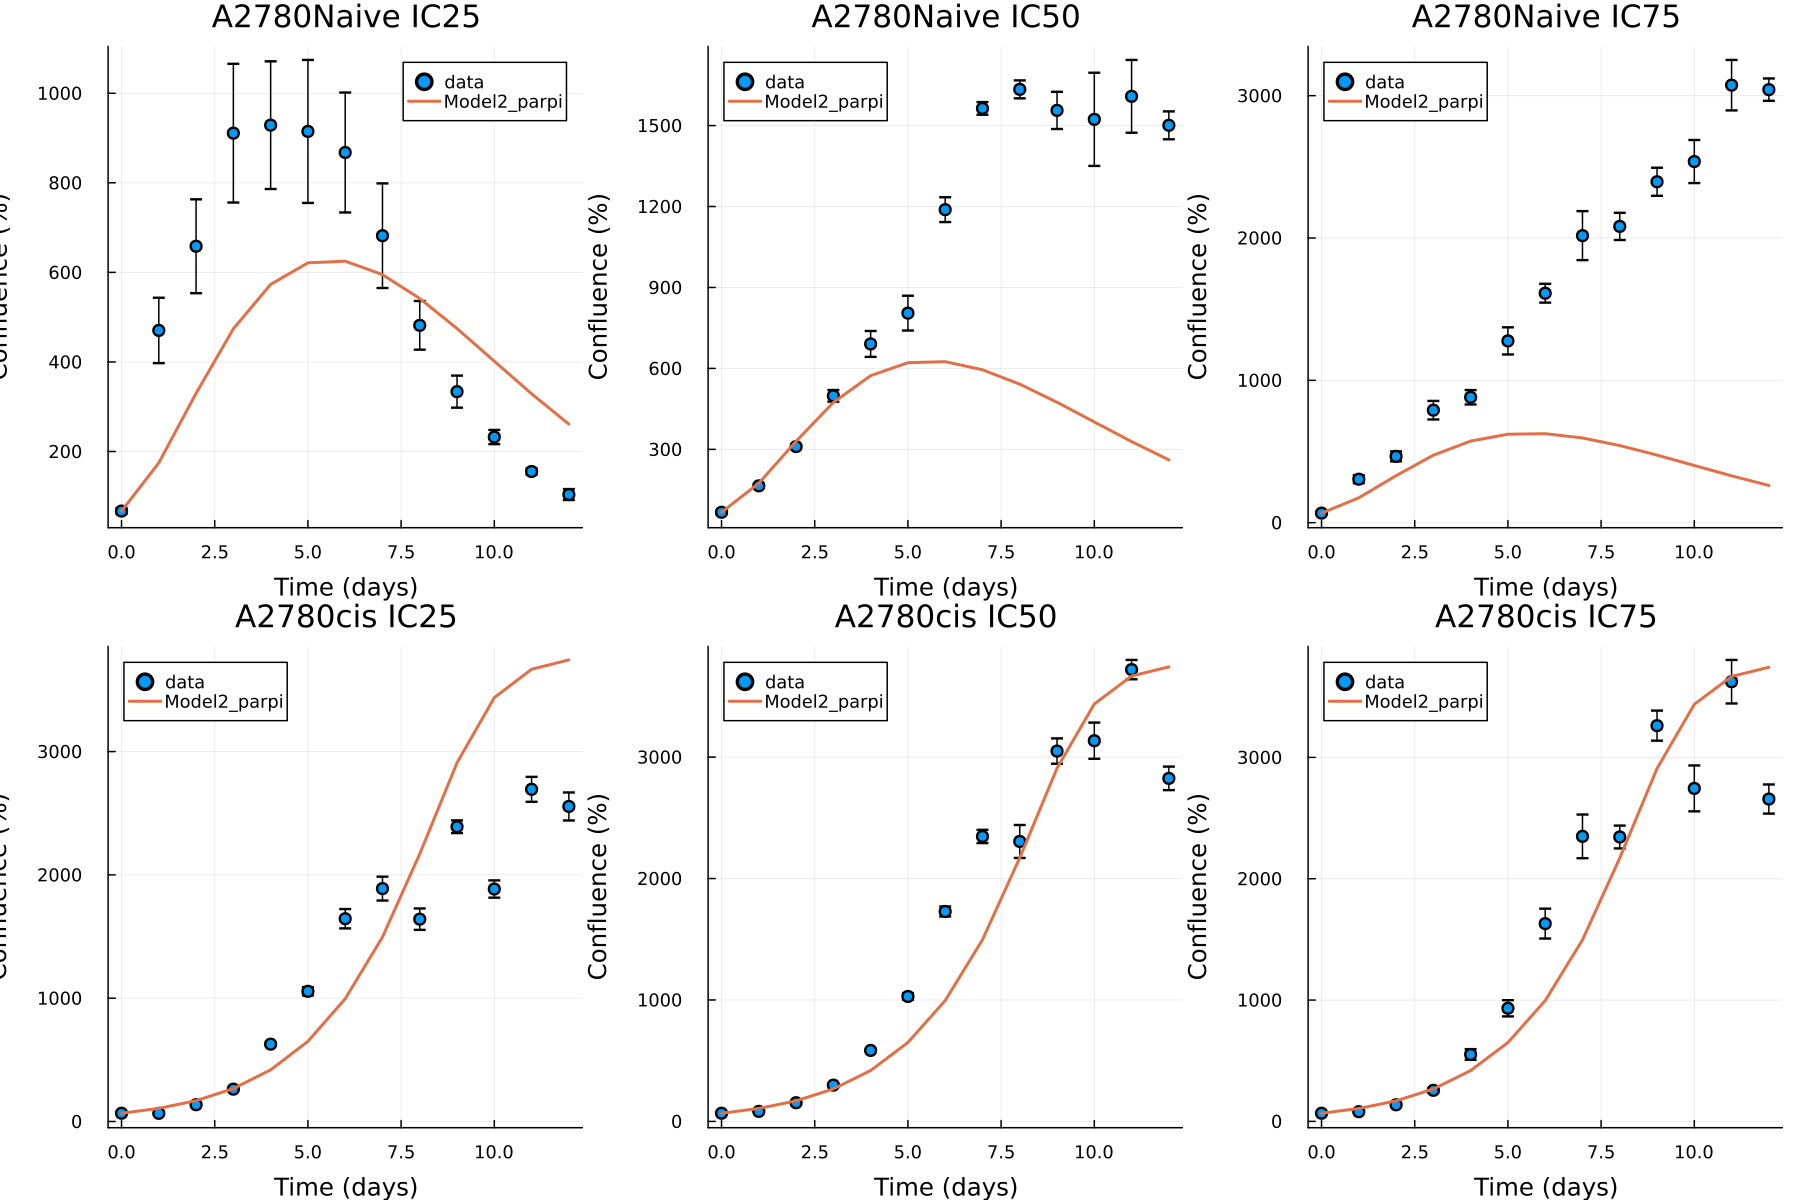

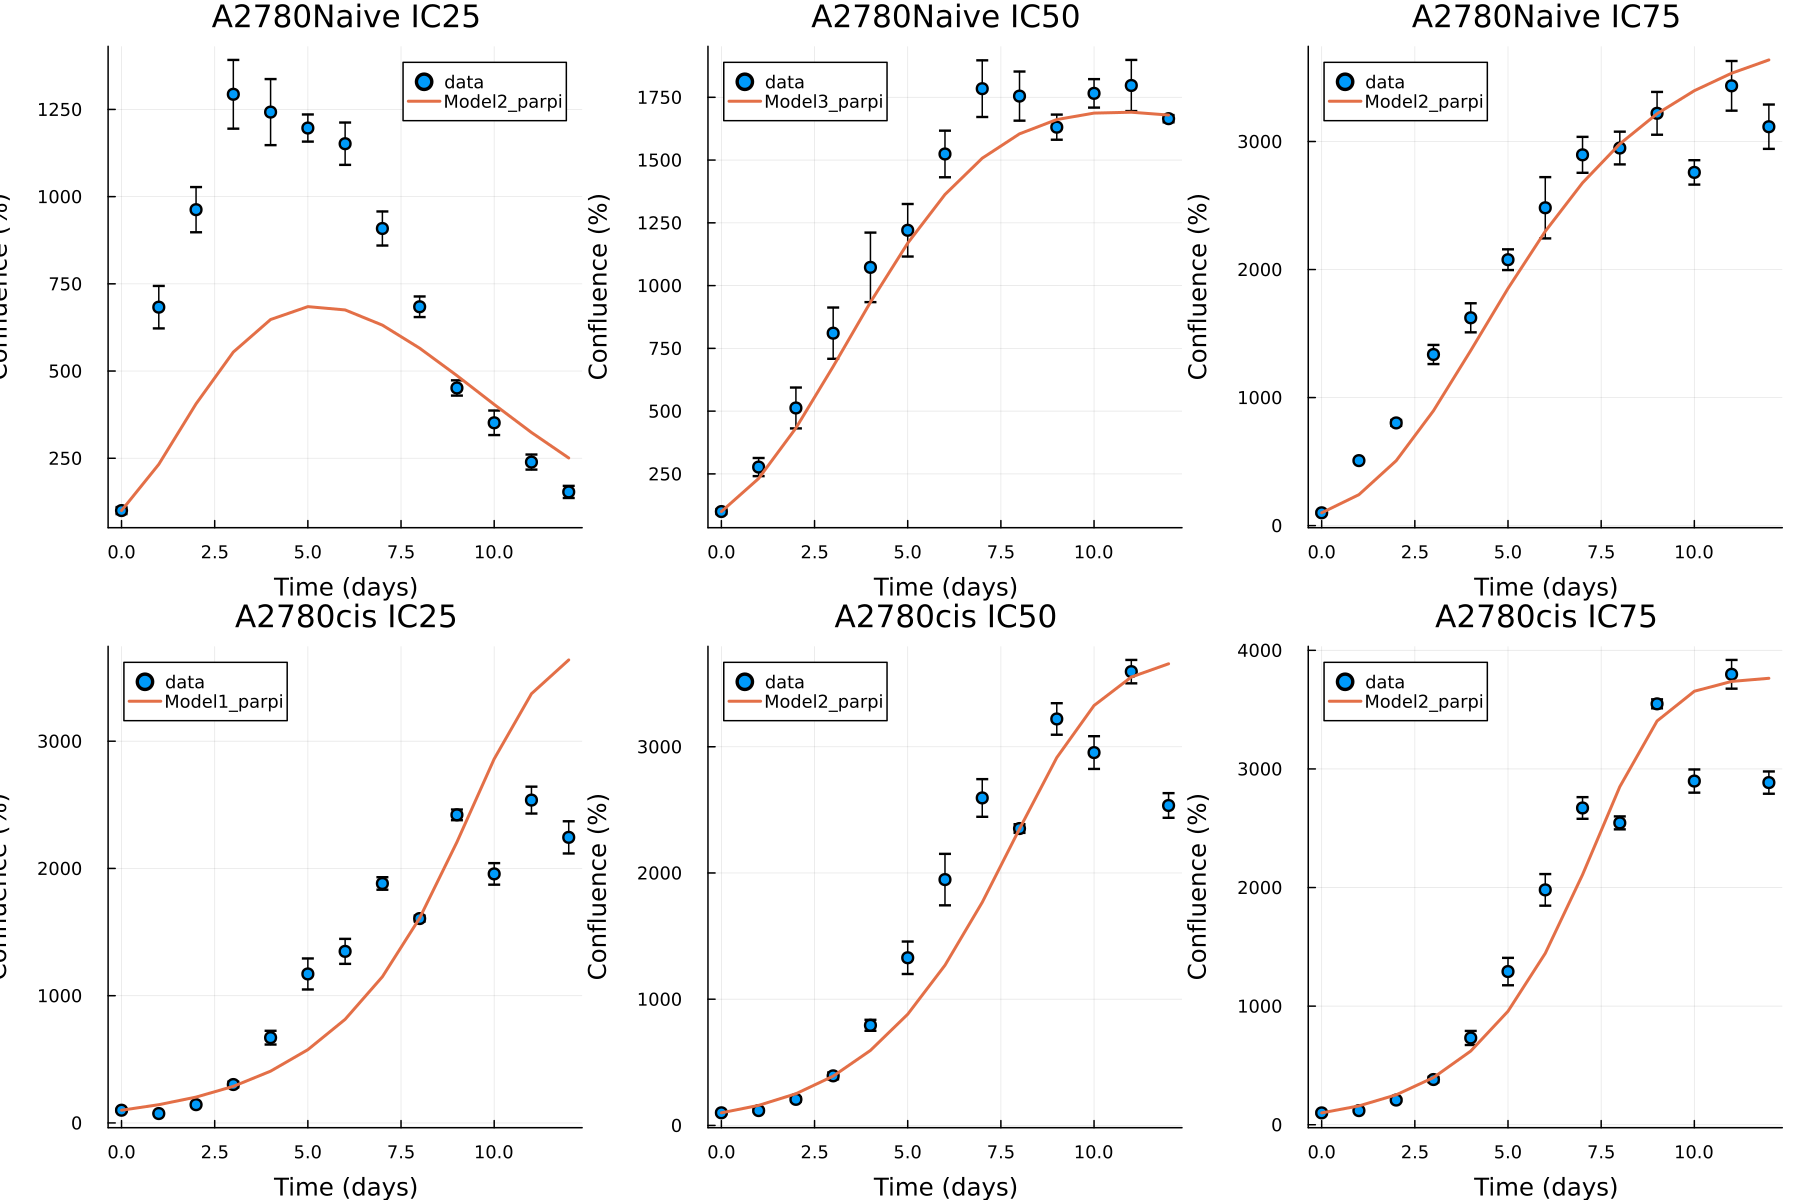

In [17]:
using CSV, DataFrames, Plots

# ------------------------------
# 6) Run across all 20k datasets
# ------------------------------

dose_dirs = Dict(
    "IC25" => IC25_DIR,
    "IC50" => IC50_DIR,
    "IC75" => IC75_DIR,
)

dose_vals = Dict(
    "IC25" => 1.47,
    "IC50" => 1.00,
    "IC75" => 0.62,
)

cell_lines = [:A2780Naive, :A2780cis]
dose_order = ("IC25", "IC50", "IC75")

all_results = Dict{Tuple{Symbol,String},Vector{NamedTuple}}()
datasets_20k = Dict{Tuple{Symbol,String},NamedTuple}()

summary_rows = DataFrame(
    cell_line = String[],
    dose_name = String[],
    model     = String[],
    sse       = Float64[],
    bic       = Float64[],
    aic       = Float64[],
)

for cl in cell_lines
    println("\n==============================")
    println("Fitting 20k datasets for cell line: ", cl)

    r, K, v = rk_params[cl]
    fixed_ic50 = cl == :A2780Naive ? 1.0 : nothing

    datasets = NamedTuple{(:dose_name,:dose_val,:x,:y,:yerr,:y0)}[]

    for dn in dose_order
        dose_dir  = dose_dirs[dn]
        dose_val  = dose_vals[dn]
        data_path = find_treated_file(dose_dir, cl)

        println("20k Dataset for ", cl, " at ", dn, ": ", data_path)

        x, y, yerr = load_day_averages_with_day0(data_path)
        nt = (
            dose_name = dn,
            dose_val  = dose_val,
            x         = x,
            y         = y,
            yerr      = yerr,
            y0        = y[1],
        )
        push!(datasets, nt)
        datasets_20k[(cl, dn)] = nt
    end

    results = [fit_shared_across_doses(m, datasets, r, K, v; fixed_ic50=fixed_ic50) for m in models]
    # store full results for each (cl, dose) combo
    for dn in dose_order
        all_results[(cl, dn)] = results
    end

    best = argmin(res -> res.bic, results)
    param_names  = best.model.pnames
    param_values = best.p̂
    params       = (; zip(param_names, param_values)...)

    println("Best model by BIC for " * String(cl) * " (20k): " * best.model.name)
    println("Parameters (shared across doses): " * string(params))
    println("SSE_total = " * string(best.sse) * ", BIC = " * string(best.bic) * ", AIC = " * string(best.aic))

    for res in results
        for d in datasets
            sse_d = dataset_sse(res.model, res.p̂, d, r, K, v; fixed_ic50=fixed_ic50)
            push!(summary_rows, (
                String(cl),
                d.dose_name,
                res.model.name,
                sse_d,
                res.bic,
                res.aic,
            ))
        end
    end
end

println("\n================ BIC/AIC summary (20k) ================")
sort!(summary_rows, [:cell_line, :dose_name, :bic])
show(summary_rows, allrows=true, allcols=true)
println()
println()

# --------- 6a) 20k: 2x3 grid of best models across cell lines × doses ---------

println("Building 2x3 grid plot for 20k datasets (best models per dataset)...")

plt20k = plot(layout = (2, 3), size = (1200, 800))

for (i_cl, cl) in enumerate(cell_lines)
    r, K, v = rk_params[cl]

    for (j_dn, dn) in enumerate(dose_order)
        idx = (i_cl - 1) * 3 + j_dn

        d = datasets_20k[(cl, dn)]
        res_vec = all_results[(cl, dn)]

        best = argmin(res -> res.bic, res_vec)
        model = best.model
        p̂ = clamp.(best.p̂, model.lower, model.upper)

        y_pred = model.simulate(d.x, p̂, d.dose_val, r, K, v, d.y0)

        plot!(plt20k[idx],
              d.x, d.y;
              yerror = d.yerr,
              seriestype = :scatter,
              label = "data",
              xlabel = "Time (days)",
              ylabel = "Confluence (%)",
              title = string(cl, " ", dn))

        plot!(plt20k[idx],
              d.x, y_pred;
              label = model.name,
              lw = 2)
    end
end

display(plt20k)
out_grid_20k = joinpath(OUT_DIR, "model_comparison_20k_grid.png")
savefig(plt20k, out_grid_20k)
println("Saved 20k 2x3 grid plot to ", out_grid_20k)


############################################
# Fit model zoo on 30k treated datasets
############################################

# 1) Directories for 30k data and outputs

IC25_DIR_30k = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "30k", "IC25", "Averages")
IC50_DIR_30k = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "30k", "IC50", "Averages")
IC75_DIR_30k = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "30k", "IC75", "Averages")

OUT_DIR_30k = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "30k", "Multi_Dose_Analysis")
isdir(OUT_DIR_30k) || mkpath(OUT_DIR_30k)

println("30k IC25 dir: ", IC25_DIR_30k)
println("30k IC50 dir: ", IC50_DIR_30k)
println("30k IC75 dir: ", IC75_DIR_30k)
println("30k output dir: ", OUT_DIR_30k)

# 2) Load baseline logistic parameters for 30k (r, K, v)

rk_df = CSV.read(RK_FILE, DataFrame)

rk_params_30k = Dict{Symbol,Tuple{Float64,Float64,Float64}}()
for row in eachrow(rk_df)
    string(row.Density) == "30k" || continue
    cl_sym = Symbol(row.CellLine)
    rk_params_30k[cl_sym] = (Float64(row.r), Float64(row.K), Float64(row.v))
end

println("rk_params_30k keys: ", collect(keys(rk_params_30k)))

# 3) Loop setup

dose_dirs_30k = Dict(
    "IC25" => IC25_DIR_30k,
    "IC50" => IC50_DIR_30k,
    "IC75" => IC75_DIR_30k,
)

dose_vals_30k = Dict(   # same doses as 20k
    "IC25" => 1.47,
    "IC50" => 1.00,
    "IC75" => 0.62,
)

all_results_30k = Dict{Tuple{Symbol,String},Vector{NamedTuple}}()
datasets_30k = Dict{Tuple{Symbol,String},NamedTuple}()

summary_rows_30k = DataFrame(
    cell_line = String[],
    dose_name = String[],
    model     = String[],
    sse       = Float64[],
    bic       = Float64[],
    aic       = Float64[],
)

# 4) Fit all models on all 30k datasets

for cl in cell_lines
    @assert haskey(rk_params_30k, cl) "No 30k rk_params for $cl"
    println("\n==============================")
    println("Fitting 30k datasets for cell line: ", cl)

    for dn in dose_order
        dose_dir  = dose_dirs_30k[dn]
        dose_val  = dose_vals_30k[dn]
        data_path = find_treated_file(dose_dir, cl)

        println("30k Dataset for ", cl, " at ", dn, ": ", data_path)

        # load data; helper already inserts day0=100 for 30k
        x, y, yerr = load_day_averages_with_day0(data_path)

        # baseline parameters for 30k
        r, K, v = rk_params_30k[cl]

        # fit all models from the existing zoo
        results = [fit_one_model(m, x, y, yerr, r, K, v, dose_val) for m in models]
        all_results_30k[(cl, dn)] = results
        datasets_30k[(cl, dn)] = (
            dose_name = dn,
            dose_val  = dose_val,
            x         = x,
            y         = y,
            yerr      = yerr,
            y0        = y[1],
        )

        # store BIC/AIC summary
        for res in results
            push!(summary_rows_30k, (
                String(cl),
                dn,
                res.model.name,
                res.sse,
                res.bic,
                res.aic,
            ))
        end

        # choose best by BIC
        best = argmin(res -> res.bic, results)
        param_names  = best.model.pnames
        param_values = best.p̂
        params       = (; zip(param_names, param_values)...)

        println("Best 30k model by BIC for ", cl, " at ", dn, ": ", best.model.name)
        println("Parameters: ", params)
        println("SSE = ", best.sse, ", BIC = ", best.bic, ", AIC = ", best.aic)
    end
end

println("\n=========== 30k BIC/AIC summary (sorted by BIC) ===========")
sort!(summary_rows_30k, [:cell_line, :dose_name, :bic])
show(summary_rows_30k, allrows=true, allcols=true)
println()

# --------- 4a) 30k: 2x3 grid of best models across cell lines × doses ---------

println("Building 2x3 grid plot for 30k datasets (best models per dataset)...")

plt30k = plot(layout = (2, 3), size = (1200, 800))

for (i_cl, cl) in enumerate(cell_lines)
    r, K, v = rk_params_30k[cl]

    for (j_dn, dn) in enumerate(dose_order)
        idx = (i_cl - 1) * 3 + j_dn

        d = datasets_30k[(cl, dn)]
        res_vec = all_results_30k[(cl, dn)]

        best = argmin(res -> res.bic, res_vec)
        model = best.model
        p̂ = clamp.(best.p̂, model.lower, model.upper)

        y_pred = model.simulate(d.x, p̂, d.dose_val, r, K, v, d.y0)

        plot!(plt30k[idx],
              d.x, d.y;
              yerror = d.yerr,
              seriestype = :scatter,
              label = "data",
              xlabel = "Time (days)",
              ylabel = "Confluence (%)",
              title = string(cl, " ", dn))

        plot!(plt30k[idx],
              d.x, y_pred;
              label = model.name,
              lw = 2)
    end
end

display(plt30k)
out_grid_30k = joinpath(OUT_DIR_30k, "model_comparison_30k_grid.png")
savefig(plt30k, out_grid_30k)
println("Saved 30k 2x3 grid plot to ", out_grid_30k)


### 5) Analysis

Total fits in summary_rows: 24

=== Global model ranking by total BIC ===
4×4 DataFrame
 Row │ model         mean_bic  sum_bic  n_datasets 
     │ String        Float64   Float64  Int64      
─────┼─────────────────────────────────────────────
   1 │ Model2_parpi   203.02   1218.12           6
   2 │ Model4_parpi   209.235  1255.41           6
   3 │ Model1_parpi   212.532  1275.19           6
   4 │ Model3_parpi   216.267  1297.6            6

Best global model by BIC: Model2_parpi
  total BIC = 1218.120593322327, mean BIC = 203.0200988870545, datasets = 6

=== Per cell-line model ranking by total BIC ===
8×5 DataFrame
 Row │ cell_line   model         mean_bic  sum_bic  n_datasets 
     │ String      String        Float64   Float64  Int64      
─────┼─────────────────────────────────────────────────────────
   1 │ A2780Naive  Model2_parpi   216.355  649.066           3
   2 │ A2780Naive  Model4_parpi   227.59   682.769           3
   3 │ A2780Naive  Model1_parpi   234.185  702.555    

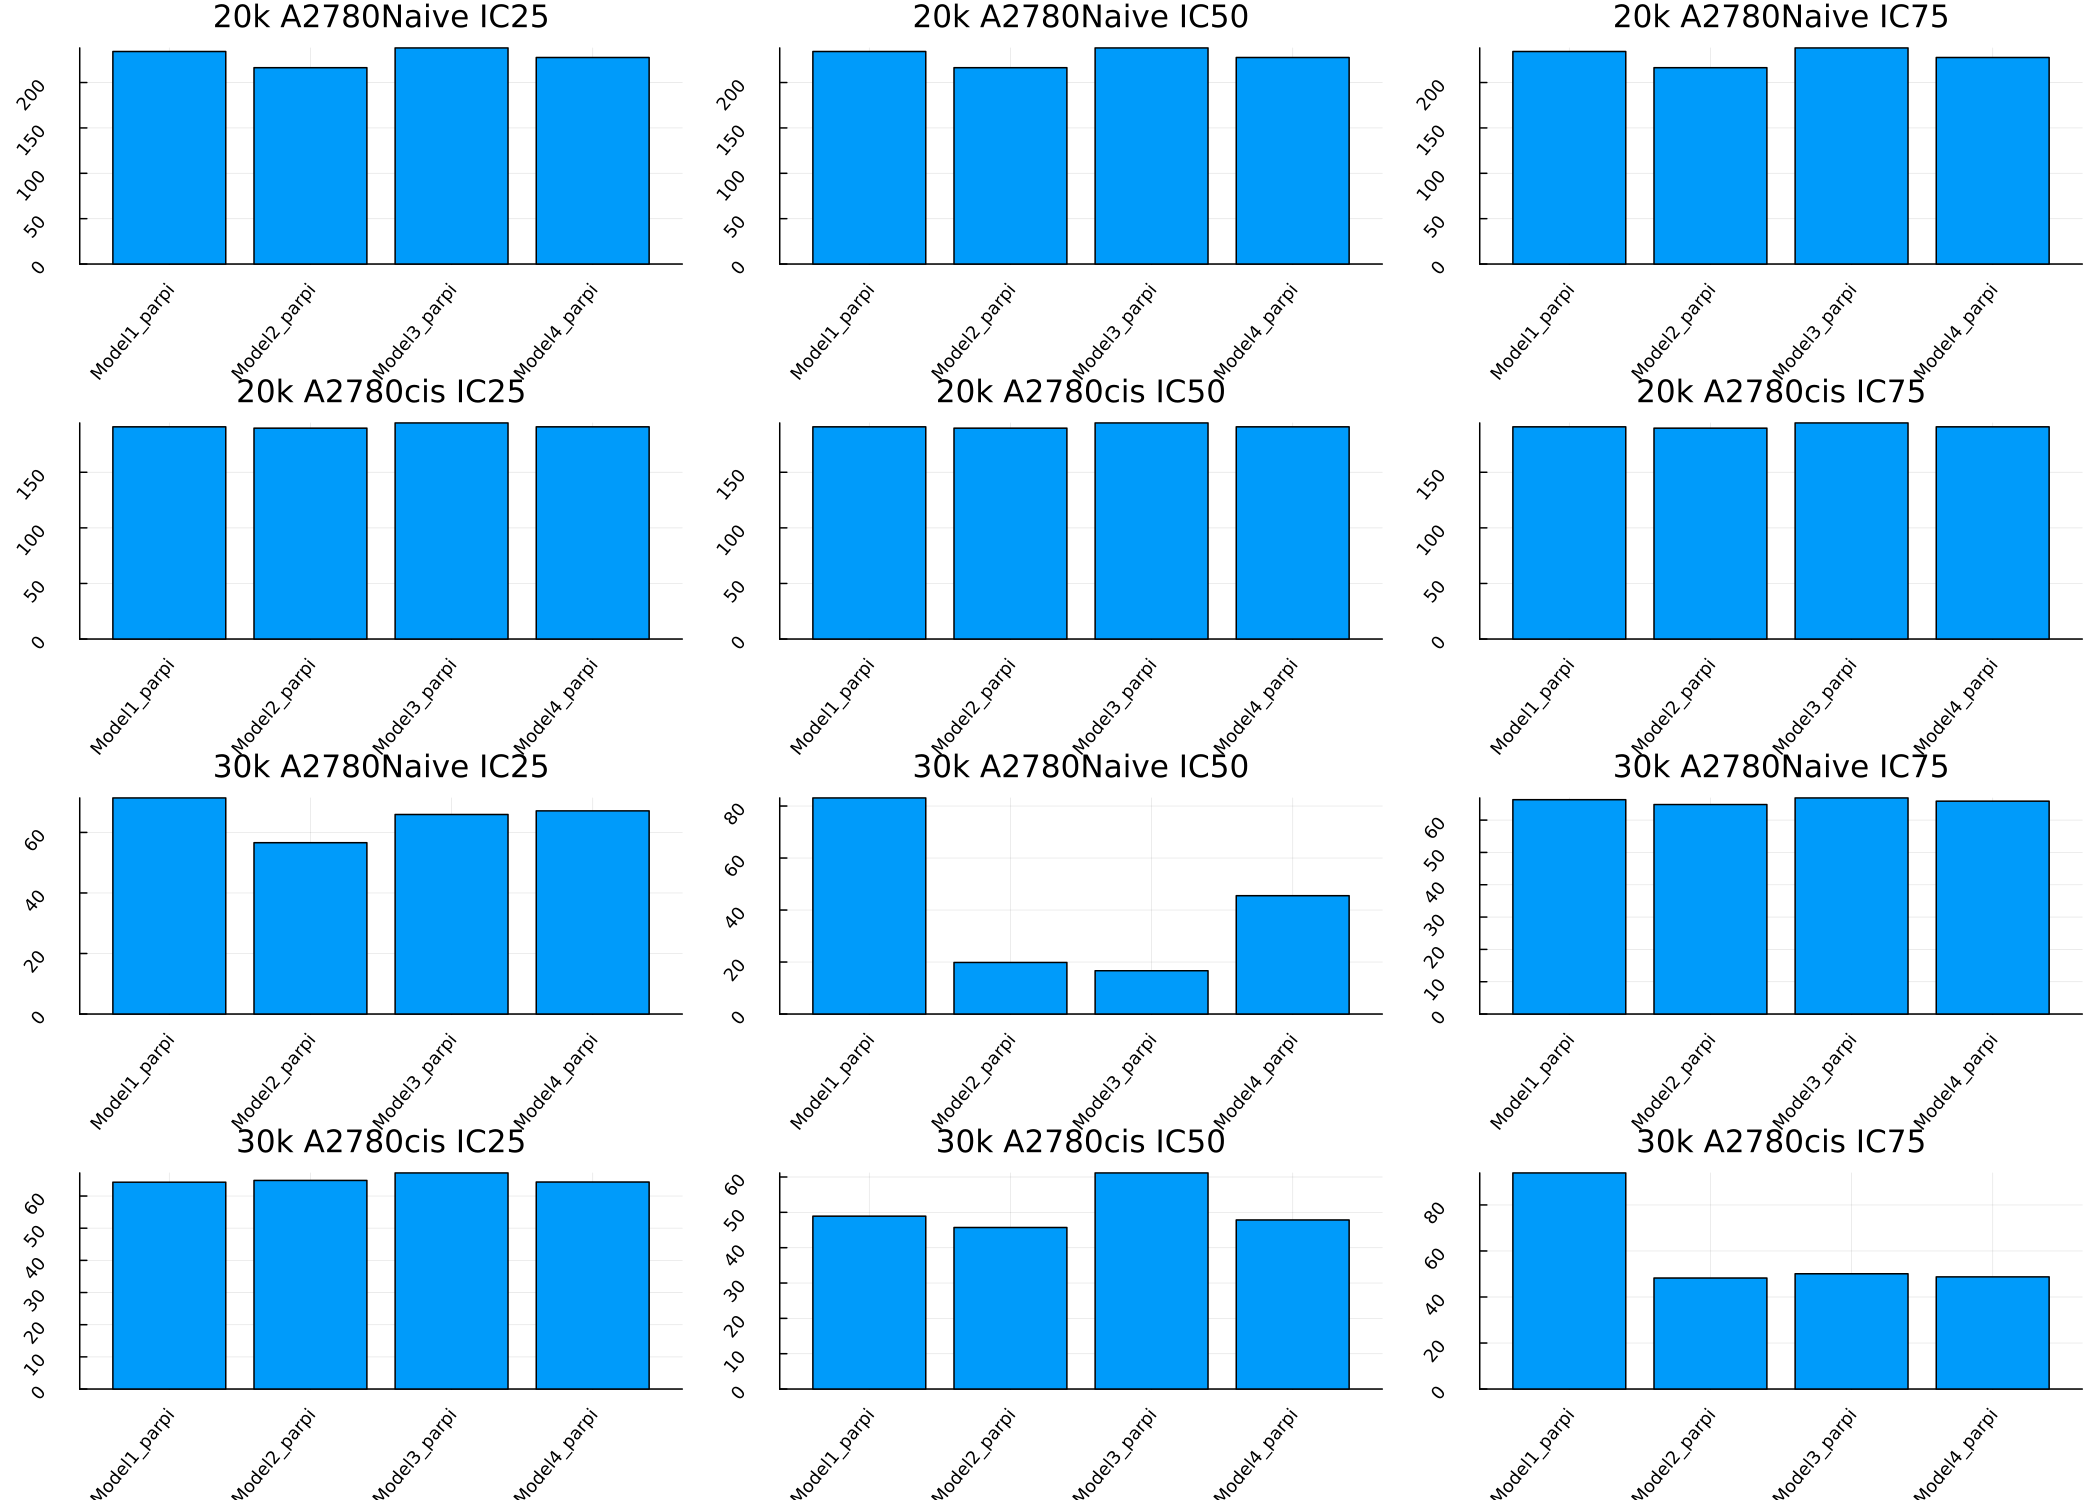

In [11]:
###############################################
# BIC ANALYSIS: GLOBAL AND PER CELL LINE 20k
###############################################

using DataFrames
using Statistics

@assert @isdefined(summary_rows) "Run the model-fit cell first."

println("Total fits in summary_rows: ", nrow(summary_rows))

# ---------- 1) Global model comparison ----------

global_stats = combine(
    groupby(summary_rows, :model)
) do sdf
    (; mean_bic = mean(sdf.bic),
       sum_bic  = sum(sdf.bic),
       n_datasets = nrow(sdf))
end

sort!(global_stats, :sum_bic)  # lower is better

println("\n=== Global model ranking by total BIC ===")
show(global_stats, allrows=true, allcols=true)
println()

best_global = global_stats[1, :]
println("\nBest global model by BIC: ", best_global.model)
println("  total BIC = ", best_global.sum_bic,
        ", mean BIC = ", best_global.mean_bic,
        ", datasets = ", best_global.n_datasets)

# ---------- 2) Per-cell-line model comparison ----------

by_cell_model = combine(
    groupby(summary_rows, [:cell_line, :model])
) do sdf
    (; mean_bic = mean(sdf.bic),
       sum_bic  = sum(sdf.bic),
       n_datasets = nrow(sdf))
end

sort!(by_cell_model, [:cell_line, :sum_bic])

println("\n=== Per cell-line model ranking by total BIC ===")
show(by_cell_model, allrows=true, allcols=true)
println()

for cl in unique(by_cell_model.cell_line)
    sub = filter(row -> row.cell_line == cl, by_cell_model)
    best = sub[1, :]
    println("\nBest model for cell line ", cl, ": ", best.model)
    println("  total BIC = ", best.sum_bic,
            ", mean BIC = ", best.mean_bic,
            ", datasets = ", best.n_datasets)
end

###############################################
# BIC ANALYSIS: GLOBAL AND PER CELL LINE 30k
###############################################

using DataFrames
using Statistics

@assert @isdefined(summary_rows_30k) "Run the model-fit cell first."

println("Total fits in summary_rows_30k: ", nrow(summary_rows_30k))

# ---------- 1) Global model comparison ----------

global_stats = combine(
    groupby(summary_rows_30k, :model)
) do sdf
    (; mean_bic = mean(sdf.bic),
       sum_bic  = sum(sdf.bic),
       n_datasets = nrow(sdf))
end

sort!(global_stats, :sum_bic)  # lower is better

println("\n=== Global model ranking by total BIC (30k) ===")
show(global_stats, allrows=true, allcols=true)
println()

best_global = global_stats[1, :]
println("\nBest global model by BIC (30k): ", best_global.model)
println("  total BIC = ", best_global.sum_bic,
        ", mean BIC = ", best_global.mean_bic,
        ", datasets = ", best_global.n_datasets)

# ---------- 2) Per-cell-line model comparison ----------

by_cell_model = combine(
    groupby(summary_rows_30k, [:cell_line, :model])
) do sdf
    (; mean_bic = mean(sdf.bic),
       sum_bic  = sum(sdf.bic),
       n_datasets = nrow(sdf))
end

sort!(by_cell_model, [:cell_line, :sum_bic])

println("\n=== Per cell-line model ranking by total BIC (30k) ===")
show(by_cell_model, allrows=true, allcols=true)
println()

for cl in unique(by_cell_model.cell_line)
    sub = filter(row -> row.cell_line == cl, by_cell_model)
    best = sub[1, :]
    println("\nBest model for cell line ", cl, " (30k): ", best.model)
    println("  total BIC = ", best.sum_bic,
            ", mean BIC = ", best.mean_bic,
            ", datasets = ", best.n_datasets)
end

# ------------------------------
# 8) Comparison tables/plots for 20k vs 30k
# ------------------------------

using DataFrames
using Statistics
using Plots

function tidy_density(df::DataFrame, density::String)
    if nrow(df) == 0
        return DataFrame()
    end
    d = copy(df)
    if :params ∉ names(d)
        d.params = fill("", nrow(d))
    end
    d.density = fill(density, nrow(d))
    return d
end

df20 = @isdefined(summary_rows)    ? tidy_density(summary_rows, "20k") : DataFrame()
df30 = @isdefined(summary_rows_30k) ? tidy_density(summary_rows_30k, "30k") : DataFrame()

df_all = vcat(df20, df30)

if nrow(df_all) == 0
    println("No summary_rows data available yet. Run the 20k and 30k fit cells first.")
else
    sort!(df_all, [:density, :cell_line, :dose_name, :bic])
    println("Full table (with params):")
    show(df_all, allrows=true, allcols=true)
    println()

    # Best model per dose/cell_line/density
    best_rows = combine(groupby(df_all, [:density, :cell_line, :dose_name])) do g
        i = argmin(g.bic)
        g[i, :]
    end
    println("\nBest models by BIC (per dose/cell_line/density):")
    show(best_rows, allrows=true, allcols=true)
    println()

    # Plot BIC by model for each dose/cell combination
    groups = collect(groupby(df_all, [:density, :cell_line, :dose_name]))
    n = length(groups)
    ncols = min(3, n == 0 ? 1 : n)
    nrows = ceil(Int, n / ncols)
    plt = plot(layout=(nrows, ncols), size=(1400, 400 + 200*max(nrows-1,0)))
    for (idx, g) in enumerate(groups)
        gp = sort(g, :model)
        sp = idx
        bar!(plt, gp.model, gp.bic; subplot=sp, legend=false,
             title=string(gp.density[1], " ", gp.cell_line[1], " ", gp.dose_name[1]),
             xticks=:auto, rotation=50)
    end
    display(plt)

    # Parameter table of best models only
    best_params = select(best_rows, [:density, :cell_line, :dose_name, :model, :params, :bic, :aic, :sse])
    println("\nBest-model parameter snapshots:")
    show(best_params, allrows=true, allcols=true)
end


In [18]:
############################################################
# Enhanced fitting: fixed vs free IC50, shared vs per-dose
############################################################

using Statistics
using Random
using Distributions

# Provide a minimal theta-logistic solver with a Hill-type ramp so the
# ramped models remain usable even if they were previously undefined.
if !@isdefined solve_treated_theta_logistic_mult_ramped
    function solve_treated_theta_logistic_mult_ramped(
        t_pts::AbstractVector,
        r::Float64, K::Float64, v::Float64;
        Emax::Float64,
        IC50::Float64,
        n::Float64,
        dose::Float64,
        y0::Float64,
        lambda::Float64 = 1.0,
        t_onset::Float64 = 0.0,
    )
        t0 = minimum(t_pts)
        tf = maximum(t_pts)

        function f!(du, u, p_, t)
            ramp = t < t_onset ? 0.0 : 1.0 - exp(-max(t - t_onset, 0.0) / lambda)
            hill = (dose^n) / (IC50^n + dose^n)
            eff  = clamp(Emax * ramp * hill, 0.0, 1.5)
            du[1] = r * (1 - eff) * u[1] * (1 - (u[1] / K)^v)
        end

        prob = ODEProblem(f!, [y0], (t0, tf))
        return solve(prob; saveat = t_pts, reltol = 1e-6, abstol = 1e-8)
    end
end

params_as_string(names, values) =
    join(["$(String(n))=$(round(v, digits = 4))" for (n, v) in zip(names, values)], ", ")

function apply_fixed_params(model::DoseResponseModel, p, fixed_params::Dict{Symbol,Float64})
    p_adj = collect(p)
    if !isempty(fixed_params)
        for (nm, val) in fixed_params
            idx = findfirst(isequal(nm), model.pnames)
            idx === nothing && continue
            lo = model.lower[idx]
            hi = model.upper[idx]
            p_adj[idx] = clamp(val, lo, hi)
        end
    end
    return p_adj
end

function information_criteria(sse::Float64, n_obs::Int, kpar::Int)
    # Estimated residual variance
    s2 = max(sse / max(n_obs, 1), 1e-12)
    bic = n_obs * log(s2) + kpar * log(max(n_obs, 2))
    aic = n_obs * log(s2) + 2kpar
    return (bic = bic, aic = aic)
end

function fit_one_model_flex(model::DoseResponseModel,
                            t, y, yerr,
                            r, K, v, dose;
                            n_starts::Int = 10,
                            fixed_params::Dict{Symbol,Float64} = Dict())
    t  = collect(Float64.(t))
    y  = collect(Float64.(y))
    ye = collect(Float64.(yerr))
    y0 = y[1]

    n_obs = length(y)
    kpar  = length(model.pnames)

    function loss(p)
        p_clamped = clamp.(p, model.lower, model.upper)
        p_clamped = apply_fixed_params(model, p_clamped, fixed_params)
        y_pred = try
            model.simulate(t, p_clamped, dose, r, K, v, y0)
        catch
            return 1e12
        end
        if length(y_pred) != n_obs
            return 1e12
        end
        w = 1.0 ./ (ye.^2 .+ 1e-12)
        return sum(w .* (y_pred .- y).^2)
    end

    best_res = nothing
    best_val = Inf

    for s in 1:n_starts
        init = [rand(Uniform(lo, hi)) for (lo, hi) in zip(model.lower, model.upper)]
        res  = Optim.optimize(
            loss, model.lower, model.upper, init,
            Fminbox(NelderMead()),
            Optim.Options(iterations = 400, show_trace = false)
        )
        val = Optim.minimum(res)
        if val < best_val
            best_val = val
            best_res = res
        end
    end

    p̂   = apply_fixed_params(model, Optim.minimizer(best_res), fixed_params)
    sse = best_val
    crit = information_criteria(sse, n_obs, kpar)

    return (model = model,
            p̂ = p̂,
            sse = sse,
            bic = crit.bic,
            aic = crit.aic)
end

function dataset_sse_flex(model::DoseResponseModel, p, dataset, r, K, v;
                          fixed_params::Dict{Symbol,Float64} = Dict())
    p_use = apply_fixed_params(model, p, fixed_params)
    y_pred = try
        model.simulate(dataset.x, p_use, dataset.dose_val, r, K, v, dataset.y0)
    catch
        return Inf
    end
    if length(y_pred) != length(dataset.y)
        return Inf
    end
    w = dataset.yerr === nothing ? ones(length(dataset.y)) :
        1.0 ./ (Float64.(dataset.yerr).^2 .+ 1e-12)
    return sum(w .* (y_pred .- Float64.(dataset.y)).^2)
end

function fit_shared_across_doses_flex(model::DoseResponseModel,
                                      datasets,
                                      r, K, v;
                                      n_starts::Int = 10,
                                      fixed_params::Dict{Symbol,Float64} = Dict())
    kpar = length(model.pnames)
    n_obs_total = sum(length(d.y) for d in datasets)

    function loss(p)
        p_clamped = clamp.(p, model.lower, model.upper)
        p_clamped = apply_fixed_params(model, p_clamped, fixed_params)
        total = 0.0
        for d in datasets
            w_sse = dataset_sse_flex(model, p_clamped, d, r, K, v; fixed_params = fixed_params)
            if !isfinite(w_sse)
                return 1e12
            end
            total += w_sse
        end
        return total
    end

    best_res = nothing
    best_val = Inf

    for s in 1:n_starts
        init = [rand(Uniform(lo, hi)) for (lo, hi) in zip(model.lower, model.upper)]
        res  = Optim.optimize(
            loss, model.lower, model.upper, init,
            Fminbox(NelderMead()),
            Optim.Options(iterations = 450, show_trace = false)
        )
        val = Optim.minimum(res)
        if val < best_val
            best_val = val
            best_res = res
        end
    end

    p̂   = apply_fixed_params(model, Optim.minimizer(best_res), fixed_params)
    sse = best_val
    crit = information_criteria(sse, n_obs_total, kpar)

    return (model = model,
            p̂ = p̂,
            sse = sse,
            bic = crit.bic,
            aic = crit.aic)
end

function run_density_fits(density_label::String,
                          dose_dirs::Dict{String,String},
                          dose_vals::Dict{String,Float64},
                          cell_lines::Vector{Symbol},
                          rk_params::Dict{Symbol,Tuple{Float64,Float64,Float64}},
                          fixed_ic50_map::Dict{Symbol,Union{Nothing,Float64}},
                          out_dir::String;
                          n_starts::Int = 12)

    summary = DataFrame(
        cell_line = String[],
        dose_name = String[],
        model     = String[],
        strategy  = String[],
        sse       = Float64[],
        bic       = Float64[],
        aic       = Float64[],
        params    = String[],
    )

    best_results = Dict{Tuple{Symbol,String},Vector{NamedTuple}}()

    for cl in cell_lines
        @assert haskey(rk_params, cl) "Missing baseline params for $(cl) at $(density_label)"
        r, K, v = rk_params[cl]
        ic50_fix = get(fixed_ic50_map, cl, nothing)

        datasets = NamedTuple{(:dose_name,:dose_val,:x,:y,:yerr,:y0)}[]
        for dn in ("IC25", "IC50", "IC75")
            data_path = find_treated_file(dose_dirs[dn], cl)
            x, y, yerr = load_day_averages_with_day0(data_path)
            push!(datasets, (
                dose_name = dn,
                dose_val  = dose_vals[dn],
                x         = x,
                y         = y,
                yerr      = yerr,
                y0        = y[1],
            ))
        end

        strategy_defs = [
            (name = "shared_freeIC50",     kind = :shared,   fixed_params = Dict{Symbol,Float64}()),
            (name = "per_dose_freeIC50",   kind = :per_dose, fixed_params = Dict{Symbol,Float64}()),
        ]
        if ic50_fix !== nothing
            push!(strategy_defs, (name = "shared_fixedIC50",   kind = :shared,   fixed_params = Dict(:IC50 => ic50_fix)))
            push!(strategy_defs, (name = "per_dose_fixedIC50", kind = :per_dose, fixed_params = Dict(:IC50 => ic50_fix)))
        end

        strategy_bic = Dict{String,Float64}()
        results_by_strategy = Dict{String,Dict{String,Vector{NamedTuple}}}()

        for strat in strategy_defs
            if strat.kind == :shared
                res_vec = [fit_shared_across_doses_flex(m, datasets, r, K, v;
                                                        fixed_params = strat.fixed_params,
                                                        n_starts = n_starts) for m in models]
                results_by_strategy[strat.name] = Dict(d.dose_name => res_vec for d in datasets)

                total_bic = 0.0
                for d in datasets
                    for res in res_vec
                        sse_d = dataset_sse_flex(res.model, res.p̂, d, r, K, v; fixed_params = strat.fixed_params)
                        crit  = information_criteria(sse_d, length(d.y), length(res.model.pnames))
                        total_bic += crit.bic
                        push!(summary, (
                            String(cl), d.dose_name, res.model.name, strat.name,
                            sse_d, crit.bic, crit.aic,
                            params_as_string(res.model.pnames, res.p̂),
                        ))
                    end
                end
                strategy_bic[strat.name] = total_bic
            else
                total_bic = 0.0
                dose_results = Dict{String,Vector{NamedTuple}}()
                for d in datasets
                    res_vec = [fit_one_model_flex(m, d.x, d.y, d.yerr, r, K, v, d.dose_val;
                                                  fixed_params = strat.fixed_params,
                                                  n_starts = n_starts) for m in models]
                    dose_results[d.dose_name] = res_vec
                    for res in res_vec
                        crit = information_criteria(res.sse, length(d.y), length(res.model.pnames))
                        total_bic += crit.bic
                        push!(summary, (
                            String(cl), d.dose_name, res.model.name, strat.name,
                            res.sse, crit.bic, crit.aic,
                            params_as_string(res.model.pnames, res.p̂),
                        ))
                    end
                end
                results_by_strategy[strat.name] = dose_results
                strategy_bic[strat.name] = total_bic
            end
        end

        best_strategy = argmin(strategy_bic)
        println("Best strategy for ", cl, " at ", density_label, ": ", best_strategy,
                " (total BIC = ", round(strategy_bic[best_strategy], digits = 3), ")")

        for d in datasets
            best_vec = results_by_strategy[best_strategy][d.dose_name]
            best_results[(cl, d.dose_name)] = best_vec
            plt_title = string(cl, " ", d.dose_name, " (", density_label, ", ", best_strategy, ")")
            plt = plot_model_comparison(d.x, d.y, d.yerr, r, K, v, d.dose_val, best_vec;
                                        title_str = plt_title)
            out_name = "model_comparison_" * String(cl) * "_" * d.dose_name * "_" *
                       density_label * "_" * best_strategy * ".png"
            savefig(plt, joinpath(out_dir, out_name))
        end
    end

    sort!(summary, [:cell_line, :dose_name, :bic])
    return summary, best_results
end

fixed_ic50_map = Dict(:A2780Naive => 1.0, :A2780cis => nothing)

# 20k enhanced fits (shared vs per-dose, fixed vs free IC50)
summary_rows, all_results = run_density_fits(
    "20k", dose_dirs, dose_vals, cell_lines, rk_params, fixed_ic50_map, OUT_DIR;
    n_starts = 12,
)

# 30k dirs and baseline params
IC25_DIR_30k = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "30k", "IC25", "Averages")
IC50_DIR_30k = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "30k", "IC50", "Averages")
IC75_DIR_30k = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "30k", "IC75", "Averages")
OUT_DIR_30k  = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "30k", "Multi_Dose_Analysis")
isdir(OUT_DIR_30k) || mkpath(OUT_DIR_30k)

dose_dirs_30k = Dict(
    "IC25" => IC25_DIR_30k,
    "IC50" => IC50_DIR_30k,
    "IC75" => IC75_DIR_30k,
)

rk_df = CSV.read(RK_FILE, DataFrame)
rk_params_30k = Dict{Symbol,Tuple{Float64,Float64,Float64}}()
for row in eachrow(rk_df)
    string(row.Density) == "30k" || continue
    rk_params_30k[Symbol(row.CellLine)] = (Float64(row.r), Float64(row.K), Float64(row.v))
end
println("30k baseline params available for: ", collect(keys(rk_params_30k)))

summary_rows_30k, all_results_30k = run_density_fits(
    "30k", dose_dirs_30k, dose_vals, cell_lines, rk_params_30k, fixed_ic50_map, OUT_DIR_30k;
    n_starts = 12,
)


Best strategy for A2780Naive at 20k: per_dose_fixedIC50 (total BIC = 484.403)
Best strategy for A2780cis at 20k: per_dose_freeIC50 (total BIC = 740.842)
30k baseline params available for: [:A2780cis, :A2780Naive]
Best strategy for A2780Naive at 30k: per_dose_freeIC50 (total BIC = 659.28)
Best strategy for A2780cis at 30k: per_dose_freeIC50 (total BIC = 672.605)


(72×8 DataFrame
 Row │ cell_line   dose_name  model         strategy            sse       bic  ⋯
     │ String      String     String        String              Float64   Floa ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ A2780Naive  IC25       Model2_parpi  per_dose_fixedIC50   559.268  56.5 ⋯
   2 │ A2780Naive  IC25       Model2_parpi  per_dose_freeIC50    559.38   56.5
   3 │ A2780Naive  IC25       Model3_parpi  per_dose_freeIC50    938.624  65.8
   4 │ A2780Naive  IC25       Model3_parpi  per_dose_fixedIC50   947.151  66.0
   5 │ A2780Naive  IC25       Model4_parpi  per_dose_freeIC50   1243.88   66.9 ⋯
   6 │ A2780Naive  IC25       Model4_parpi  per_dose_fixedIC50  1253.51   67.0
   7 │ A2780Naive  IC25       Model1_parpi  per_dose_freeIC50   1746.07   71.3
   8 │ A2780Naive  IC25       Model1_parpi  per_dose_fixedIC50  1746.07   71.3
  ⋮  │     ⋮           ⋮           ⋮                ⋮              ⋮         ⋮ ⋱
  66 │ A2780cis    IC75 

In [ ]:
############################################################
# PARPi Model 2 with simplified logistic baselines
############################################################

simple_param_file = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_all_models_parameters.csv")
@assert isfile(simple_param_file) "Missing simplified logistic parameter file: $(simple_param_file)"

function load_simple_logistic_params(file::AbstractString)
    df = CSV.read(file, DataFrame)

    required = [:CellLine, :Model, :r, :K, :BIC]
    missing = setdiff(required, Symbol.(names(df)))
    @assert isempty(missing) "Missing columns: $(missing)"

    df_log = filter(row -> lowercase(String(row.Model)) == "logistic", df)
    @assert nrow(df_log) > 0 "No logistic rows found in $(file)"

    grouped = groupby(df_log, :CellLine)
    params = Dict{Symbol,Tuple{Float64,Float64,Float64}}()
    for sub in grouped
        best = sub[argmin(sub.BIC), :]
        v_val = try
            Float64(best.v)
        catch
            NaN
        end
        if isnan(v_val)
            v_val = 1.0
        end
        params[Symbol(best.CellLine)] = (Float64(best.r), Float64(best.K), v_val)
    end
    return params
end

simple_rk = load_simple_logistic_params(simple_param_file)
println("Using simplified logistic params from untreated_monoculture_all_models_parameters.csv")
for (cl, (r, K, v)) in simple_rk
    println("  $(String(cl)): r=$(round(r, digits=4)), K=$(round(K, digits=1)), v=$(round(v, digits=3))")
end

format_params(names, vals) = join(["$(String(n))=$(round(v, digits=4))" for (n, v) in zip(names, vals)], ", ")

parpi2_simplified = Dict{Symbol,NamedTuple}()

for cl in cell_lines
    @assert haskey(simple_rk, cl) "No simplified params for $(cl)"
    r, K, v = simple_rk[cl]
    fixed_ic50 = cl == :A2780Naive ? 1.0 : nothing

    datasets = NamedTuple{(:dose_name,:dose_val,:x,:y,:yerr,:y0)}[]
    for dn in dose_order
        data_path = find_treated_file(dose_dirs[dn], cl)
        x, y, yerr = load_day_averages_with_day0(data_path)
        push!(datasets, (
            dose_name = dn,
            dose_val  = dose_vals[dn],
            x         = x,
            y         = y,
            yerr      = yerr,
            y0        = y[1],
        ))
    end

    res = fit_shared_across_doses(model2_parpi, datasets, r, K, v; fixed_ic50 = fixed_ic50)
    parpi2_simplified[cl] = res

    println("\n== PARPi Model 2 with simplified logistic baselines for ", cl, " ==")
    println("BIC = ", res.bic, ", AIC = ", res.aic, ", SSE = ", res.sse)
    println("Parameters: ", format_params(model2_parpi.pnames, res.p̂))
end
